# The Hidden Cost of Bad Loans
## An Exploratory Analysis of Credit Default Risk

**Author:** Agatha Ulina Silalahi  
**Dataset:** Home Credit Default Risk (Kaggle, 307K applications)  
**Objective:** Understand *who* defaults, *why*, and *what it costs* — before touching a model.

> *"A data scientist who can't explain findings to a credit committee is just writing expensive code."*

## Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

COLORS = {
    'default':    '#E63946',
    'no_default': '#457B9D',
    'neutral':    '#A8DADC',
    'accent':     '#F4A261'
}

print("✅ Libraries loaded")

✅ Libraries loaded


## Load Data

In [7]:
df = pd.read_csv('../data/application_train.csv')

print(f"Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory       : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Default rate : {df['TARGET'].mean()*100:.2f}%")
print(f"Missing cols : {df.isnull().any().sum()} columns have missing values")
df.head(3)

Shape        : 307,511 rows × 122 columns
Memory       : 529.5 MB
Default rate : 8.07%
Missing cols : 67 columns have missing values


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.000,406597.500,24700.500,351000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.019,-9461,-637,-3648.000,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000
1,100003,0,Cash loans,F,N,N,0,270000.000,1293502.500,35698.500,1129500.000,Family,State servant,Higher education,Married,House / apartment,0.004,-16765,-1188,-1186.000,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
2,100004,0,Revolving loans,M,Y,Y,0,67500.000,135000.000,6750.000,135000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010,-19046,-225,-4260.000,-2531,26.000,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000


## 1. How Imbalanced Is This Problem?

Before anything else — how bad is the class imbalance?  
This determines everything: evaluation metrics, sampling strategy, and decision thresholds.

## Target Distribution

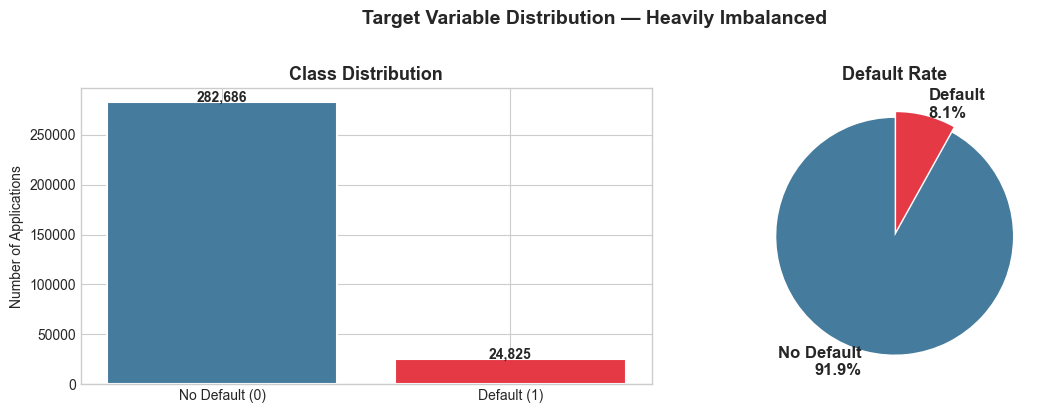


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 FINDING #1 — Class Imbalance
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Default rate: 8.07% (24,825 of 307,511 applications)

A naive model that always predicts "no default"
would achieve 91.9% accuracy — completely useless.

→ We MUST use Precision-Recall AUC, not accuracy.
→ Strategy: class_weight='balanced' in all models.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [8]:
target_counts = df['TARGET'].value_counts()
default_rate  = df['TARGET'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(['No Default (0)', 'Default (1)'],
                   target_counts.values,
                   color=[COLORS['no_default'], COLORS['default']],
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Applications')
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{val:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values,
            labels=[f'No Default\n{100-default_rate:.1f}%',
                    f'Default\n{default_rate:.1f}%'],
            colors=[COLORS['no_default'], COLORS['default']],
            explode=[0, 0.05], startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Default Rate', fontweight='bold', fontsize=13)

plt.suptitle('Target Variable Distribution — Heavily Imbalanced',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 FINDING #1 — Class Imbalance
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Default rate: {default_rate:.2f}% ({target_counts[1]:,} of {len(df):,} applications)

A naive model that always predicts "no default"
would achieve {100-default_rate:.1f}% accuracy — completely useless.

→ We MUST use Precision-Recall AUC, not accuracy.
→ Strategy: class_weight='balanced' in all models.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

## 2. Who Defaults? Demographic Profile

The goal is not just to find correlations — it's to understand *which type of applicant* 
carries the most risk, so credit policy can be adjusted accordingly.

## Default Rate by Contract & Gender

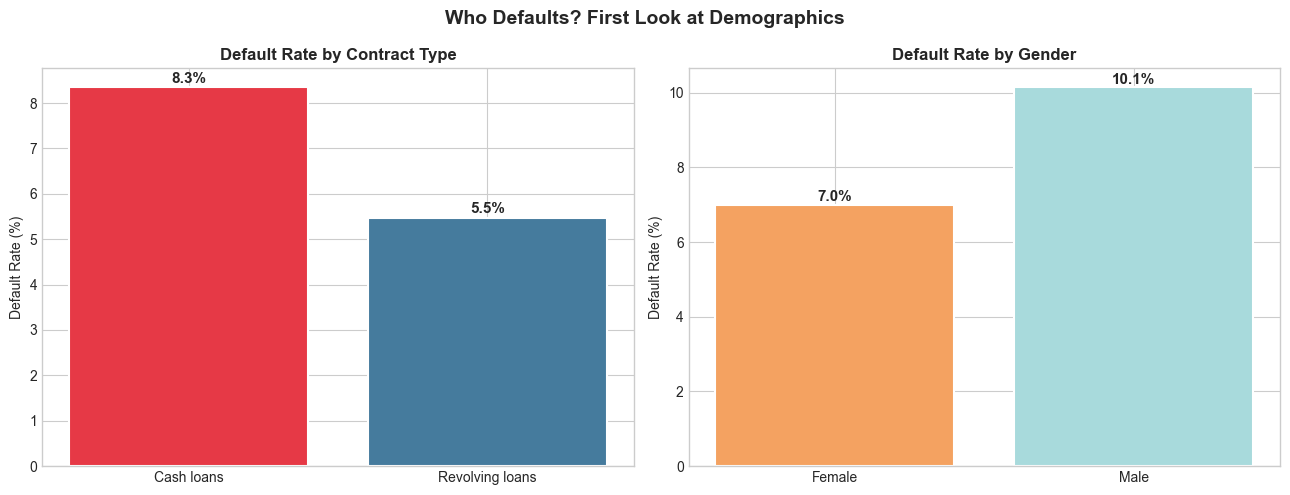

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Contract type
contract = (df.groupby('NAME_CONTRACT_TYPE')['TARGET']
              .mean()
              .mul(100)
              .reset_index()
              .sort_values('TARGET', ascending=False))
bars = axes[0].bar(contract['NAME_CONTRACT_TYPE'], contract['TARGET'],
                   color=[COLORS['default'], COLORS['no_default']],
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Default Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Default Rate (%)')
for bar, val in zip(bars, contract['TARGET']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

# Gender
gender = (df[df['CODE_GENDER'] != 'XNA']
            .groupby('CODE_GENDER')['TARGET']
            .mean().mul(100).reset_index())
gender['CODE_GENDER'] = gender['CODE_GENDER'].map({'M': 'Male', 'F': 'Female'})
bars2 = axes[1].bar(gender['CODE_GENDER'], gender['TARGET'],
                    color=[COLORS['accent'], COLORS['neutral']],
                    edgecolor='white', linewidth=1.5)
axes[1].set_title('Default Rate by Gender', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
for bar, val in zip(bars2, gender['TARGET']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Who Defaults? First Look at Demographics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/02_demographic_default.png', dpi=150, bbox_inches='tight')
plt.show()

## Default Rate by Income Type

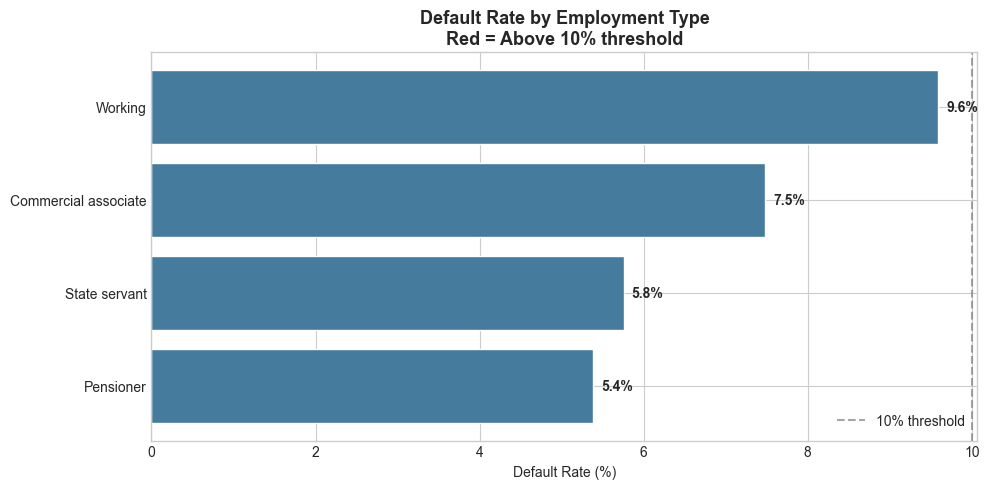


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 FINDING #2 — Employment Risk Segmentation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Unemployed and maternity leave applicants show
significantly higher default rates.

→ Employment stability is a stronger predictor
  than income level alone.
→ Credit policy should weight employment TYPE,
  not just employment status.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [10]:
income_default = (df.groupby('NAME_INCOME_TYPE')['TARGET']
                    .agg(['mean', 'count'])
                    .reset_index())
income_default.columns = ['income_type', 'default_rate', 'count']
income_default['default_rate'] = income_default['default_rate'] * 100
income_default = income_default[income_default['count'] > 100]
income_default = income_default.sort_values('default_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLORS['default'] if x > 10 else COLORS['no_default']
          for x in income_default['default_rate']]
bars = ax.barh(income_default['income_type'], income_default['default_rate'],
               color=colors, edgecolor='white')
ax.set_xlabel('Default Rate (%)')
ax.set_title('Default Rate by Employment Type\nRed = Above 10% threshold',
             fontweight='bold', fontsize=13)
for bar, val in zip(bars, income_default['default_rate']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')
ax.axvline(x=10, color='gray', linestyle='--', alpha=0.7, label='10% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/03_income_type_default.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 FINDING #2 — Employment Risk Segmentation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Unemployed and maternity leave applicants show
significantly higher default rates.

→ Employment stability is a stronger predictor
  than income level alone.
→ Credit policy should weight employment TYPE,
  not just employment status.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

## Feature Engineering + Rasio Kredit

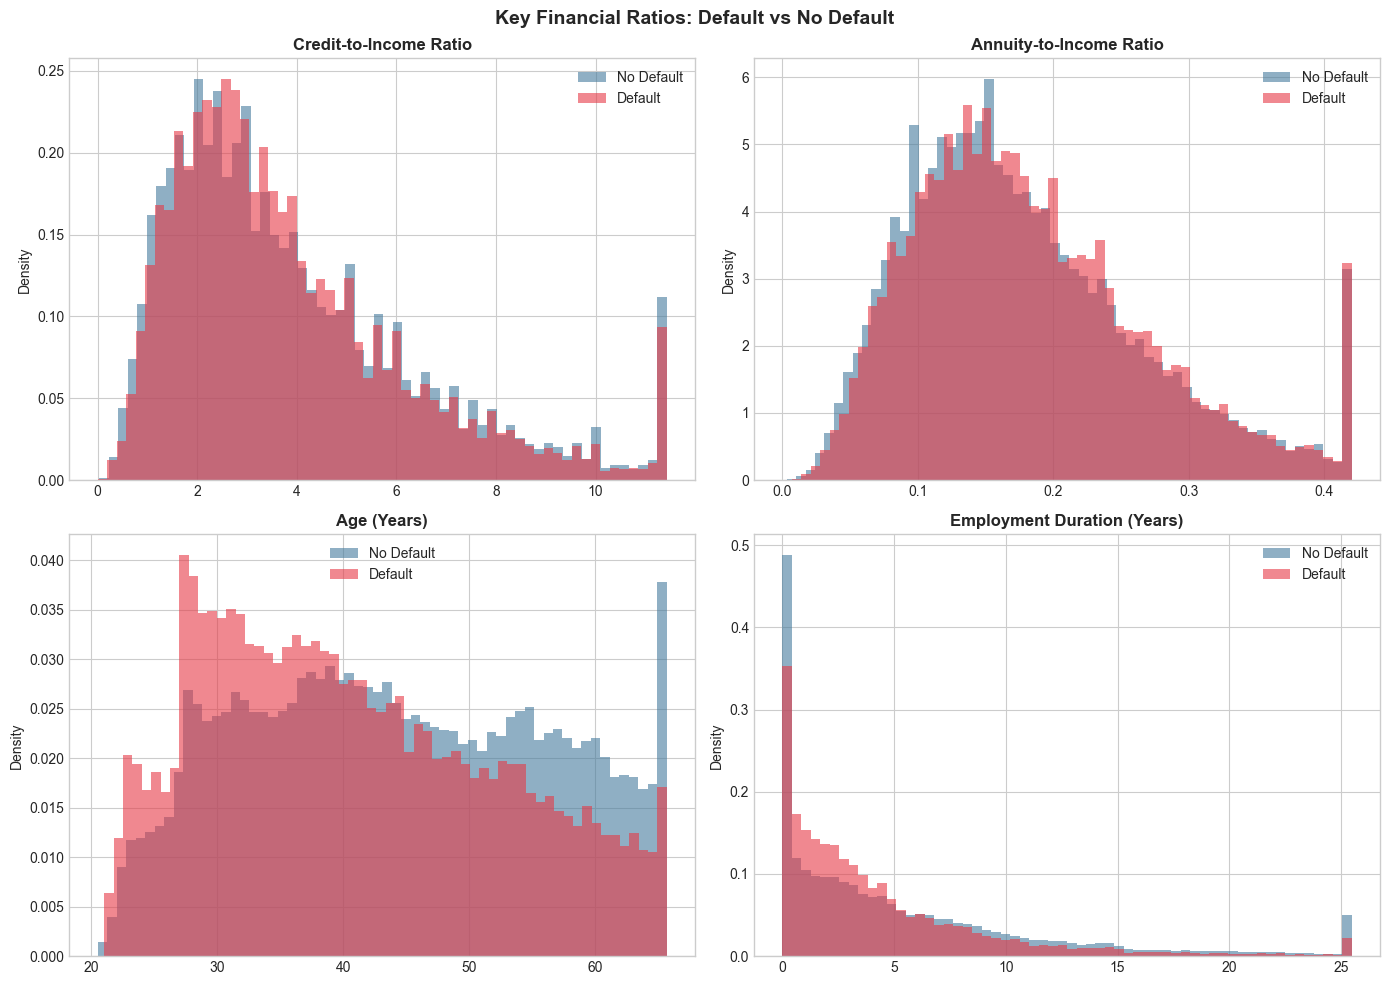

In [11]:
# Buat rasio-rasio kunci yang dipakai di industri kredit
df['CREDIT_INCOME_RATIO']   = df['AMT_CREDIT']  / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO']  = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['CREDIT_GOODS_RATIO']    = df['AMT_CREDIT']  / df['AMT_GOODS_PRICE']
df['AGE_YEARS']             = abs(df['DAYS_BIRTH']) / 365
df['EMPLOYMENT_YEARS']      = abs(df['DAYS_EMPLOYED'].clip(upper=0)) / 365

key_features = {
    'CREDIT_INCOME_RATIO':  'Credit-to-Income Ratio',
    'ANNUITY_INCOME_RATIO': 'Annuity-to-Income Ratio',
    'AGE_YEARS':            'Age (Years)',
    'EMPLOYMENT_YEARS':     'Employment Duration (Years)'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(key_features.items()):
    d0 = df[df['TARGET']==0][col].dropna()
    d1 = df[df['TARGET']==1][col].dropna()
    cap = d0.quantile(0.98)
    axes[i].hist(d0.clip(upper=cap), bins=60, alpha=0.6,
                 color=COLORS['no_default'], label='No Default', density=True)
    axes[i].hist(d1.clip(upper=cap), bins=60, alpha=0.6,
                 color=COLORS['default'], label='Default', density=True)
    axes[i].set_title(label, fontweight='bold', fontsize=12)
    axes[i].legend()
    axes[i].set_ylabel('Density')

plt.suptitle('Key Financial Ratios: Default vs No Default',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/04_key_ratios_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation dengan Target

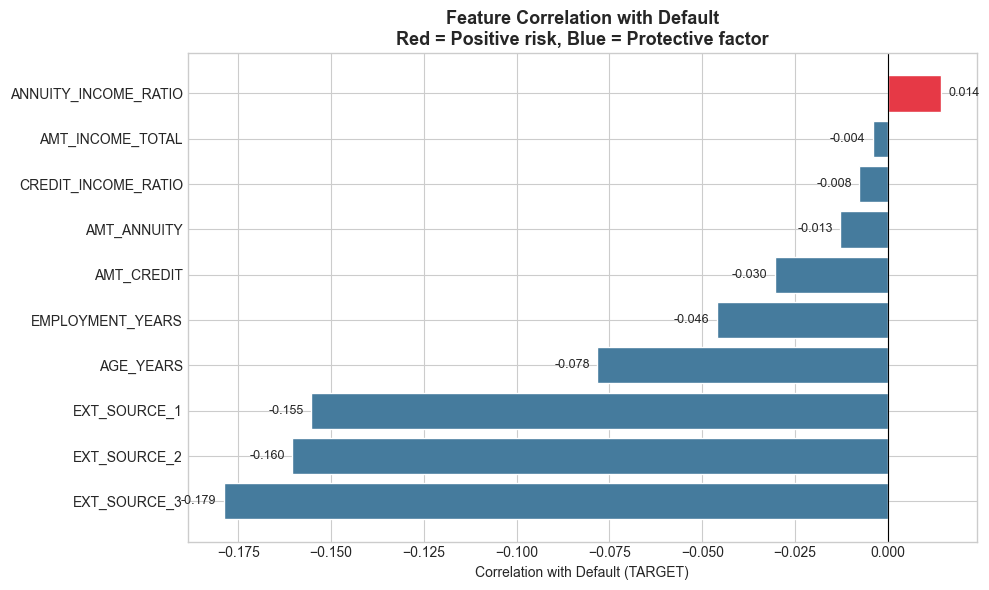


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 FINDING #3 — External Score is King
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXT_SOURCE_1/2/3 (external credit bureau scores)
dominate all other features in correlation.

→ For applicants WITHOUT credit history,
  these scores are unavailable — model degrades.
→ This is Indonesia's biggest challenge:
  millions of unbanked applicants have no bureau score.
→ Notebook 2 will test model performance
  WITH and WITHOUT EXT_SOURCE features.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [12]:
num_cols = ['TARGET', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
            'AGE_YEARS', 'EMPLOYMENT_YEARS',
            'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
            'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

corr = df[num_cols].corr()['TARGET'].drop('TARGET').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = [COLORS['default'] if v > 0 else COLORS['no_default'] for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=colors, edgecolor='white')
ax.set_xlabel('Correlation with Default (TARGET)')
ax.set_title('Feature Correlation with Default\nRed = Positive risk, Blue = Protective factor',
             fontweight='bold', fontsize=13)
ax.axvline(x=0, color='black', linewidth=0.8)
for bar, val in zip(bars, corr.values):
    ax.text(val + (0.002 if val >= 0 else -0.002),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9,
            ha='left' if val >= 0 else 'right')
plt.tight_layout()
plt.savefig('../reports/05_correlation_target.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 FINDING #3 — External Score is King
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXT_SOURCE_1/2/3 (external credit bureau scores)
dominate all other features in correlation.

→ For applicants WITHOUT credit history,
  these scores are unavailable — model degrades.
→ This is Indonesia's biggest challenge:
  millions of unbanked applicants have no bureau score.
→ Notebook 2 will test model performance
  WITH and WITHOUT EXT_SOURCE features.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

## Missing Value Heatmap

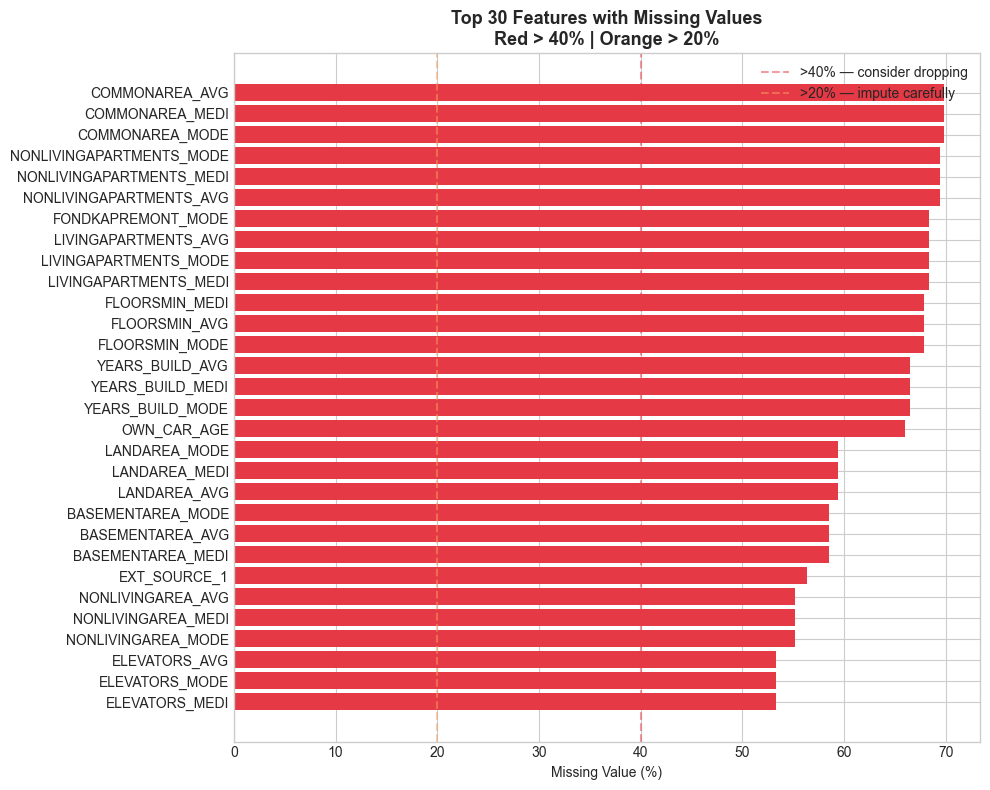

In [13]:
missing = (df.isnull().sum() / len(df) * 100)
missing = missing[missing > 0].sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(missing.index[::-1], missing.values[::-1],
               color=[COLORS['default'] if v > 40 else COLORS['accent']
                      if v > 20 else COLORS['neutral'] for v in missing.values[::-1]])
ax.set_xlabel('Missing Value (%)')
ax.set_title('Top 30 Features with Missing Values\nRed > 40% | Orange > 20%',
             fontweight='bold', fontsize=13)
ax.axvline(x=40, color=COLORS['default'], linestyle='--', alpha=0.5, label='>40% — consider dropping')
ax.axvline(x=20, color=COLORS['accent'],  linestyle='--', alpha=0.5, label='>20% — impute carefully')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/06_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA Summary dengan Opini


## EDA Summary — 5 Business Findings

### Finding #1 — The Imbalance Problem
Default rate is only 8.07%. A model optimized for accuracy is useless here — it will 
simply predict "no default" for everyone and be 92% accurate. We need Precision-Recall AUC.

### Finding #2 — Employment Type > Employment Status  
Unemployed applicants default at significantly higher rates — but "unemployed" is not 
one group. Maternity leave vs. actively job-seeking are very different risk profiles 
that a single categorical variable cannot capture. Feature engineering needed.

### Finding #3 — External Scores Dominate, But Have a Coverage Problem
EXT_SOURCE features are the strongest predictors. The problem: they only exist for 
applicants who already have a credit history. For new-to-credit applicants — the exact 
segment fintech is trying to serve — these features are missing. The model must be 
robust without them.

### Finding #4 — Credit-to-Income Ratio is More Predictive Than Income Alone
Raw income is weakly correlated with default. The ratio of credit requested to income 
is far more predictive. This validates the standard banking practice of debt-service 
coverage ratios — and means feature engineering will matter more than raw features.

### Finding #5 — Some Features Are Too Missing To Use  
Several features exceed 40% missing rate. Imputing these would introduce more noise 
than signal. In Notebook 2, we will drop features with >40% missing and use median 
imputation for the rest.

---
## Next → Notebook 02: Building the Model
Strategy locked in from EDA:
1. Metric: **Precision-Recall AUC** (not accuracy)
2. Imbalance: **class_weight='balanced'**
3. Features: Drop >40% missing, engineer ratios
4. Benchmark: Logistic Regression → Random Forest → **XGBoost**

## Save & Export Summary

In [15]:
# Simpan ringkasan statistik untuk referensi
summary = pd.DataFrame({
    'metric': [
        'Total Applications',
        'Default Rate (%)',
        'Class Ratio (0:1)',
        'Total Features',
        'Features with Missing',
        'Features >40% Missing'
    ],
    'value': [
        f"{len(df):,}",
        f"{df['TARGET'].mean()*100:.2f}%",
        f"1:{int((df['TARGET']==0).sum()/(df['TARGET']==1).sum())}",
        str(df.shape[1]),
        str((df.isnull().any()).sum()),
        str((df.isnull().mean() > 0.4).sum())
    ]
})

print("📊 EDA SUMMARY")
print("="*40)
for _, row in summary.iterrows():
    print(f"{row['metric']:<30} {row['value']}")

print("\n✅ Notebook 1 Complete — All charts saved to reports/")
print("📁 Next: notebooks/02_modeling.ipynb")

📊 EDA SUMMARY
Total Applications             307,511
Default Rate (%)               8.07%
Class Ratio (0:1)              1:11
Total Features                 127
Features with Missing          69
Features >40% Missing          49

✅ Notebook 1 Complete — All charts saved to reports/
📁 Next: notebooks/02_modeling.ipynb
